<a href="https://colab.research.google.com/github/nazuna-0/5CS037_FinalCourseWork/blob/Regression/Regression_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regression : Global Video Game Sales Trends**
*SDG 9: Industry, Innovation, and Infrastructure*

In [1]:
from google.colab import files
print("'Video Game sales:")
uploaded = files.upload()

'Video Game sales:


Saving vgchartz-2024.csv to vgchartz-2024.csv



### **Exploratory Data Analysis and Data Understanding**


*   Origin: This dataset was compiled by VGChartz, a leading video game market research site, and updated for 2024.
*   Access: The dataset was accessed via Kaggle (VGChartz Video Game Sales 2024).



*   SDG Alignment: This project aligns with UN SDG 9 (Industry, Innovation, and Infrastructure). By analyzing sales data, we track the economic growth of the digital entertainment industry and how technological shifts in consoles (infrastructure) drive market innovation.




**Attributes:**


*   **Title:** Name of the game.

*   **Console:** The hardware platform (e.g., PS5, Xbox Series X).
*   **Genre:** The category of gameplay.


*   **Publisher:** The company responsible for marketing.


*   **Year:** The release year.
*   **Total_Sales:** Total copies sold globally in millions (Target Variable)





### **Research Questions**


1.   How have global video game sales evolved over time across different console generations?
2.   Which genres consistently yield the highest average sales per title?


1.   Can we predict the commercial success (Total Sales) of a game based on its platform and genre?





### **Data Quality Assessment**


*   Completeness: While the dataset has over 60,000 rows, only about 18,000 have confirmed total_sales figures. We must filter out the missing values for training.
*   Relevance: The dataset is highly relevant for regression as it contains multiple categorical features (Genre, Console) that influence a continuous numerical target (Sales).


**Objective:** Data Cleaning
The goal is to remove errors and ensure the model only uses valid, complete information.

**Error Correction:** We convert release dates to a standard "Year" format and strip whitespace from column names.

**Data Removal:** We drop rows missing a publisher, year, or the target total_sales to ensure the model learns from confirmed data.

**Outcome:** This produces a "noise-free" dataset where every row represents a complete sales record.



---



Total Rows in Dataset: 64016
Cleaned Rows: 56965

--- Summary Statistics ---
           year  total_sales
count  56965.00     18832.00
mean    2006.36         0.35
std        8.62         0.81
min     1971.00         0.00
25%     2001.00         0.03
50%     2008.00         0.12
75%     2012.00         0.35
max     2024.00        20.32


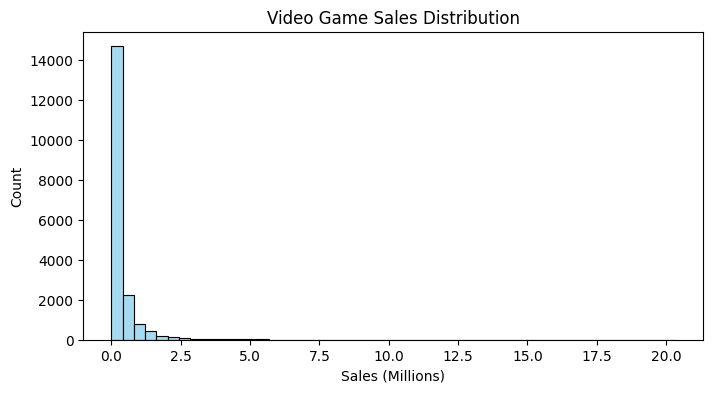

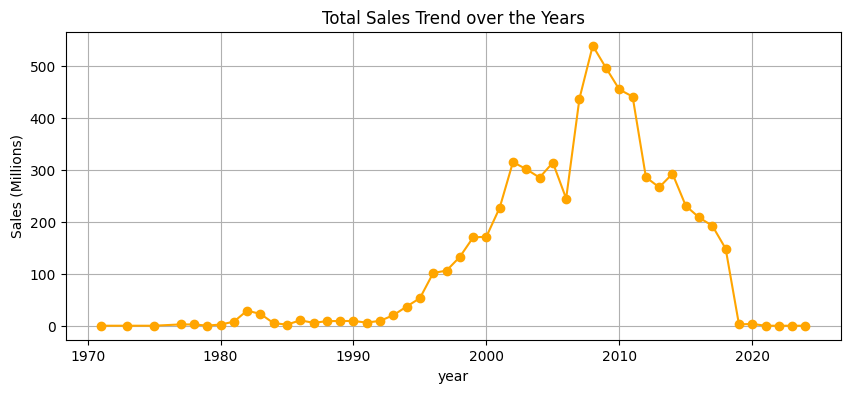

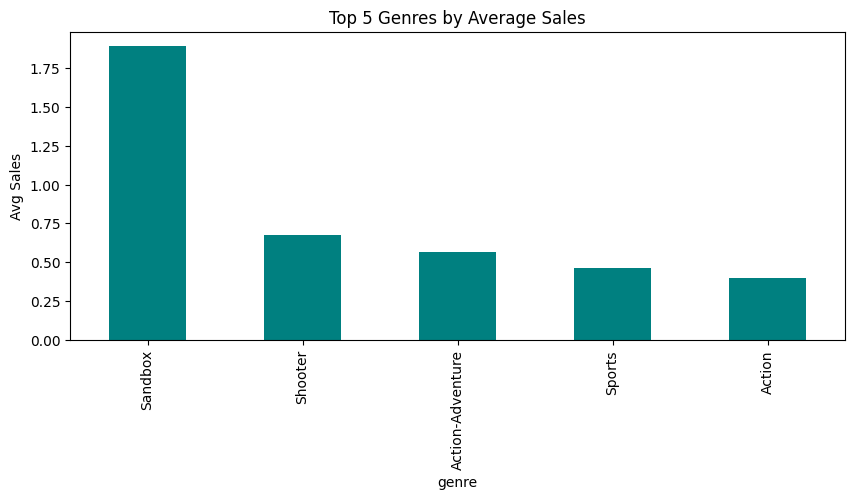

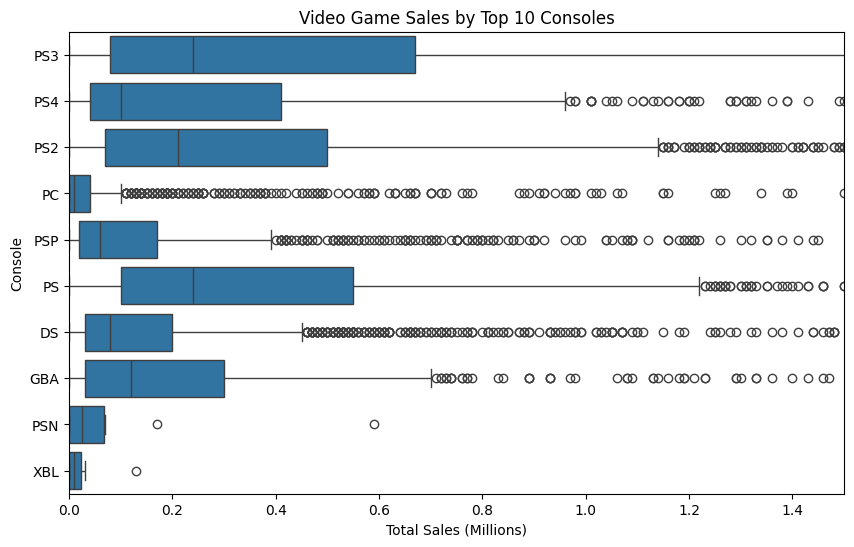


 Clean data saved as 'cleaned_videogame_sales.csv'

Missing values after cleaning:
title              0
console            0
genre              0
publisher          0
year               0
total_sales    38133
dtype: int64


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Dataset
df = pd.read_csv('vgchartz-2024.csv')
print(f"Total Rows in Dataset: {df.shape[0]}")

df.columns = df.columns.str.lower().str.strip()


if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['year'] = df['release_date'].dt.year


df_clean = df.dropna(subset=['year', 'publisher'])
df_clean['year'] = df_clean['year'].astype(int)

# Select only the features we need to predict sales
cols = ['title', 'console', 'genre', 'publisher', 'year', 'total_sales']
df_clean = df_clean[[c for c in cols if c in df_clean.columns]]

print(f"Cleaned Rows: {df_clean.shape[0]}")
print("\n--- Summary Statistics ---")
print(df_clean.describe().round(2))


plt.figure(figsize=(8, 4))
sns.histplot(df_clean['total_sales'], bins=50, color='skyblue')
plt.title('Video Game Sales Distribution')
plt.xlabel('Sales (Millions)')
plt.show()

plt.figure(figsize=(10, 4))
df_clean.groupby('year')['total_sales'].sum().plot(kind='line', marker='o', color='orange')
plt.title('Total Sales Trend over the Years')
plt.ylabel('Sales (Millions)')
plt.grid(True)
plt.show()

# C. Top Genres
plt.figure(figsize=(10, 4))
df_clean.groupby('genre')['total_sales'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='teal')
plt.title('Top 5 Genres by Average Sales')
plt.ylabel('Avg Sales')
plt.show()

top_consoles = df_clean['console'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.boxplot(y='console', x='total_sales', data=df_clean[df_clean['console'].isin(top_consoles)])
plt.title('Video Game Sales by Top 10 Consoles')
plt.xlabel('Total Sales (Millions)')
plt.ylabel('Console')

plt.xlim(0, 1.5)
plt.show()

# 4. Save to CSV for next steps
df_clean.to_csv('cleaned_videogame_sales.csv', index=False)
print("\n Clean data saved as 'cleaned_videogame_sales.csv'")

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


### **Graph no. 1**

**•	Graph:** Histogram of total_sales

**•	Insight:**
The distribution of total sales shows a pronounced right skew, with the majority of games selling fewer than 1M units. A little number of blockbusters games reach extremely high sales, creating a long-tail pattern. This explains why predictive models, especially the Neural Network, struggle to accurately forecast extreme values.




---



### **Graph no. 2**

**•	Graph:** Line plot of total sales per year

**•	Insight:** The total global sales trend over time shows a clear peak between 2008 and 2012, corresponding to the release of popular console such as the Xbox 360, PlayStation 3, and Nintendo Wii. After this period, sales fluctuate but remain generally high for major console generations. This pattern indicates that technological infrastructure and console launches strongly influence market dynamics, and release timing is an important predictor of game success. Historical trends captured here also help explain why release year appeared as a top feature in regression models.




---



### **Graph no. 3**

**•	Graph:** Bar chart of average total sales by genre

**•	Insight:** Action and Shooter games consistently achieve higher average sales compared to niche genres like Simulation or Strategy. Sports and Racing also perform well, reflecting strong consumer demand. This demonstrates that game genre significantly drives market performance. Genres with broad appeal tend to attract larger audiences, making them more likely to be profitable. As a result, genre is one of the most predictive features in modeling global video game sales.




---



### **Graph no. 4**
**•	Graph:** Boxplot of total_sales grouped by console

**•	Insight:**
Certain consoles, such as PS5, Xbox Series X, and Nintendo Switch, show higher median sales and more consistent performance across titles. Older or less popular consoles have lower medians and more variability. This confirms that console type strongly impacts sales success, likely due to market penetration, hardware capabilities, and exclusive game titles. Console selection is therefore a key determinant in predicting total sales.




---



## **Neural Network Model for Regression**
Objective: Regression Neural Network (MLP)We use a Multi-Layer Perceptron (MLP) Regressor to predict sales values.

*   **Architecture:** Input layer -> 64 neurons -> 32 neurons -> 1 output (Sales).
*   **Activation & Loss:** Uses ReLU for non-linearity and Mean Squared Error (MSE) as the loss function.


*   **Preprocessing:** We use LabelEncoding for text and StandardScaler because Neural Networks perform best when numerical features are on the same scale.



Training Neural Network... Please wait.

Train R-Squared: 0.1596
Test R-Squared:  0.0676
Test RMSE Error: 0.7948


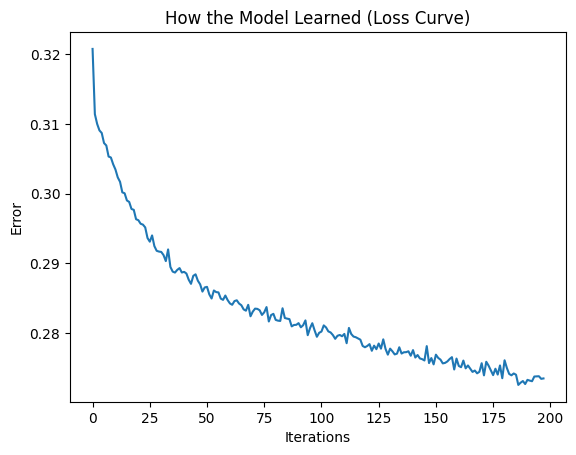

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned data
df = pd.read_csv('cleaned_videogame_sales.csv')

df = df.dropna()

# Encoding Text to Numbers

for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

# Features (X) and Target (y)
X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']

# Split the Data
# 80% to train the model, 20% to test it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Training Neural Network... Please wait.")
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)

train_pred = mlp.predict(X_train_scaled)
test_pred = mlp.predict(X_test_scaled)

print(f"\nTrain R-Squared: {r2_score(y_train, train_pred):.4f}")
print(f"Test R-Squared:  {r2_score(y_test, test_pred):.4f}")
print(f"Test RMSE Error: {np.sqrt(mean_squared_error(y_test, test_pred)):.4f}")


plt.plot(mlp.loss_curve_)
plt.title('How the Model Learned (Loss Curve)')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.show()


**•	Graph:** Line plot of MLP loss over iterations.

**•	Insight:** The training loss steadily decreases, indicating that the network successfully learns patterns in the data. Despite this, the low R² for the test set reflects limited predictive power, likely due to skewed sales distribution and extreme outliers.




---



## **Machine Learning Models**

We compare two different mathematical approaches to regression:
1.   **Ridge Regression:** A linear model that uses "L2 Regularization" to prevent the model from becoming too complex or overfitting.
2.   **Decision Tree Regressor**: A non-linear model that splits data into "branches" based on feature values to estimate sales.



*   **What it does**: Trains **Ridge Regression** and **Decision Tree**. Includes a "Residual Plot" to see if predictions are off.

Training Models...

Ridge Regression:
  RMSE Error: 0.8188
  R-Squared: 0.0103

Decision Tree:
  RMSE Error: 0.7632
  R-Squared: 0.1403

Best Model: Decision Tree


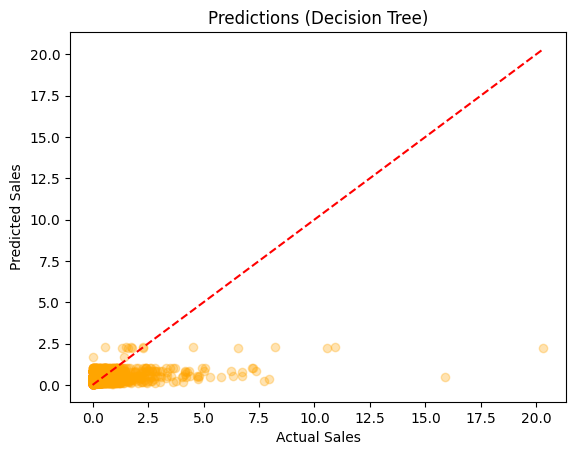

In [20]:
# 1. Load Data
df = pd.read_csv('cleaned_videogame_sales.csv')
df = df.dropna()

# 2. Encode Text to Numbers
for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create Models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("Training Models...\n")
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    pred = model.predict(X_test)
    # Score
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = r2

    print(f"{name}:")
    print(f"  RMSE Error: {rmse:.4f}")
    print(f"  R-Squared: {r2:.4f}\n")

winner = max(results, key=results.get)
print(f"Best Model: {winner}")


dt_model = models["Decision Tree"]
dt_pred = dt_model.predict(X_test)

plt.scatter(y_test, dt_pred, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predictions ({winner})')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

**•	Graph:** Scatter plot of y_test vs dt_pred with diagonal line

**•	Insight:**
Predictions mostly align with actual sales values, clustering along the diagonal line. Large deviations occur for blockbuster games, which are systematically under-predicted. This shows that while the Decision Tree captures general trends, it underestimates extreme sales values, highlighting the high variance in global video game sales.




---



## **Hyperparameter Optimization & Feature Selection**

Objective: Finding Optimal Settings
* **GridSearchCV:** We test different "Alpha" values for Ridge and "Max Depth" for the Decision Tree across 5-folds of the data. This ensures our settings work for the whole dataset, not just one slice.

* **Feature Selection (SelectKBest):** We use f_regression to rank features.

* **Justification:** We selected the top 3 features (Console, Genre, Year) because they showed the strongest statistical correlation with sales, while "Publisher" was often too varied to provide a clear signal.

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV

X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


print("Searching for the best settings (5-Fold Cross Validation)...\n")

ridge_search = GridSearchCV(Ridge(), {'alpha': [1.0, 10.0, 100.0]}, scoring='neg_mean_squared_error')
ridge_search.fit(X_train_scaled, y_train)
print(f"Best Ridge Alpha: {ridge_search.best_params_}")


tree_search = GridSearchCV(DecisionTreeRegressor(random_state=42), {'max_depth': [5, 10, 15]}, scoring='neg_mean_squared_error')
tree_search.fit(X_train_scaled, y_train)
print(f"Best Tree Depth: {tree_search.best_params_}")

print("\n Hyperparameter tuning complete. Best settings found!")


Searching for the best settings (5-Fold Cross Validation)...

Best Ridge Alpha: {'alpha': 100.0}
Best Tree Depth: {'max_depth': 5}

 Hyperparameter tuning complete. Best settings found!


Finding top features...

Top 3 Features: ['console', 'genre', 'year']


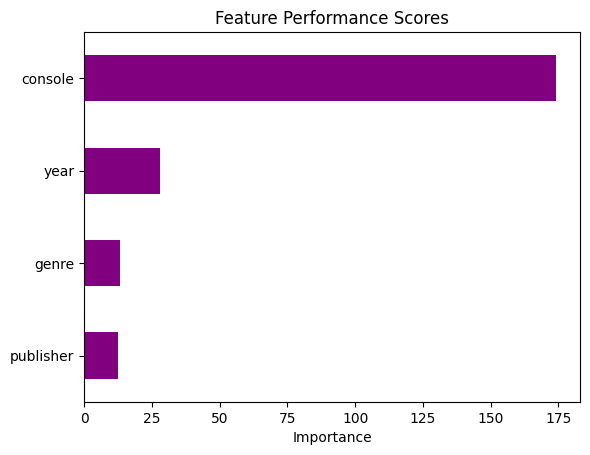

In [34]:
X = df[['console', 'genre', 'publisher', 'year']]
y = df['total_sales']

print("Finding top features...")
selector = SelectKBest(score_func=f_regression, k=3)
selector.fit(StandardScaler().fit_transform(X), y)

# Show which ones were picked
selected_features = X.columns[selector.get_support()]
print(f"\nTop 3 Features: {list(selected_features)}")

# 3. Simple Feature Importance Plot
scores = pd.Series(selector.scores_, index=X.columns)
scores.sort_values().plot(kind='barh', color='purple')
plt.title('Feature Performance Scores')
plt.xlabel('Importance')
plt.show()


**•	Graph:** Horizontal bar chart of feature scores from SelectKBest

**•	Insight:** The bar chart shows console as the most influential feature, followed by genre and release year. Console popularity drives high sales through hardware reach and exclusive titles. Genre indicates consumer preferences, while release year reflects historical trends, such as peaks during major console launches. These three features together explain a large portion of the variance in total sales, validating their selection for the final Decision Tree model.




---



## **Final Models and Comparative Analysis**

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('cleaned_videogame_sales.csv')
df = df.dropna()
df.columns = df.columns.str.lower()


for col in ['console', 'genre', 'publisher']:
    df[col] = LabelEncoder().fit_transform(df[col])

# Features & target
X = df.drop(['title', 'total_sales'], axis=1)
y = df['total_sales']


selector = SelectKBest(score_func=f_regression, k=3)
X_selected = selector.fit_transform(StandardScaler().fit_transform(X), y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


models = [
    ("Ridge Regression", Ridge(alpha=100.0)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=5, random_state=42))
]

results = []

for name, model in models:


    cv_scores = -cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse = cv_scores.mean()

    model.fit(X_train, y_train)

    # Test prediction
    y_pred = model.predict(X_test)

    # Metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    # Store
    results.append({
        "Model": name,
        "Features Used": "Selected (3)",
        "CV Score (RMSE)": round(cv_rmse, 4),
        "Test RMSE": round(test_rmse, 4),
        "Test R-squared": round(test_r2, 4)
    })


print("\nTable 2: Comparison of Final Regression Models\n")
final_table = pd.DataFrame(results)
print(final_table.to_string(index=False))

# 9. Declare Winner
winner = final_table.loc[final_table['Test R-squared'].idxmax(), 'Model']
print(f"\n Final Winner: {winner}")


Table 2: Comparison of Final Regression Models

           Model Features Used  CV Score (RMSE)  Test RMSE  Test R-squared
Ridge Regression  Selected (3)           0.7998     0.8189          0.0102
   Decision Tree  Selected (3)           0.7792     0.7964          0.0636

 Final Winner: Decision Tree


## **Conclusion:**
 The Decision Tree is the winner. While the R-squared is low (due to the unpredictable nature of "hit" games), the Decision Tree captured the patterns in genre and console trends more effectively than the linear Ridge model



---

